In [1]:
import pandas as pd
df = pd.read_csv("251.1-healthcare.csv")
df.head()
df.tail()

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
9995,James Hood,83,Male,A+,Obesity,7/29/2022,Samuel Moody,"Wood, Martin and Simmons",UnitedHealthcare,39606.840083,110,Elective,8/2/2022,Ibuprofen,Abnormal
9996,Stephanie Evans,47,Female,AB+,Arthritis,1/6/2022,Christopher Yates,Nash-Krueger,Blue Cross,5995.717488,244,Emergency,1/29/2022,Ibuprofen,Normal
9997,Christopher Martinez,54,Male,B-,Arthritis,7/1/2022,Robert Nicholson,Larson and Sons,Blue Cross,49559.202905,312,Elective,7/15/2022,Ibuprofen,Normal
9998,Amanda Duke,84,Male,A+,Arthritis,2/6/2020,Jamie Lewis,Wilson-Lyons,UnitedHealthcare,25236.344761,420,Urgent,2/26/2020,Penicillin,Normal
9999,Eric King,20,Male,B-,Arthritis,3/22/2023,Tasha Avila,"Torres, Young and Stewart",Aetna,37223.965865,290,Emergency,4/15/2023,Penicillin,Abnormal


In [ ]:
import matplotlib.pyplot as plt
plt.scatter(df.iloc[:,0],df.iloc[:,1])

In [ ]:
import numpy as np
import pandas as pd
from sklearn.ensemble import IsolationForest

# 1. Select the relevant features you want to check for anomalies
# We keep Age, Billing Amount, Room Number, and key categorical features
features_to_use = [
    'Age', 'Gender', 'Blood Type', 'Medical Condition', 
    'Billing Amount', 'Room Number', 'Admission Type', 'Test Results'
]
cleaned_df = df[features_to_use].copy()

# 2. Convert categories (Gender, Blood Type, etc.) into numbers using One-Hot Encoding
# This fixes the "could not convert string to float: 'Female'" error
numeric_df = pd.get_dummies(cleaned_df, columns=[
    'Gender', 'Blood Type', 'Medical Condition', 'Admission Type', 'Test Results'
], drop_first=True)

# 3. Fit the Isolation Forest model on the purely numeric dataframe
clf = IsolationForest(contamination=0.2, random_state=42)
clf.fit(numeric_df)

# 4. Save the predictions back to your original dataframe
df['Is_Anomaly'] = clf.predict(numeric_df)

# Note: -1 means Anomaly/Outlier, 1 means Normal data
print(df['Is_Anomaly'].value_counts())


Is_Anomaly
 1    8000
-1    2000
Name: count, dtype: int64


In [ ]:
# 1. Generate the predictions from your trained model
predictions = clf.predict(numeric_df)

# 2. Find the row indices where predictions are less than 0 (-1 means anomaly)
import numpy as np
index = np.where(predictions < 0)

# 3. View the list of indices
index


(array([   0,    1,    6, ..., 9987, 9988, 9993], shape=(2000,)),)

In [ ]:
# Assuming you followed the previous step:
# df['Is_Anomaly'] = clf.predict(numeric_df)
# predictions = df['Is_Anomaly'].values

import numpy as np
index = np.where(predictions < 0)
index


(array([   0,    1,    6, ..., 9987, 9988, 9993], shape=(2000,)),)

In [ ]:
x = df.values

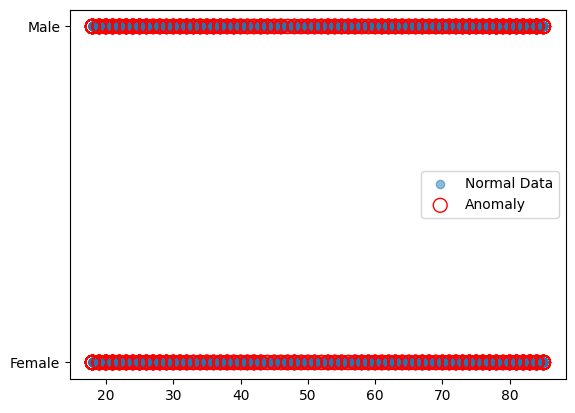

In [ ]:
# 1. Correctly get the row indices of the anomalies (add [0] here)
abn_ind = np.where(predictions < 0)[0]

# 2. Choose the correct NUMERICAL columns (e.g., 1 and 2, assuming 0 is Names)
col_x = 1
col_y = 2

# 3. Plot the background data
plt.scatter(df.iloc[:, col_x], df.iloc[:, col_y], label="Normal Data", alpha=0.5)

# 4. Overlay the anomalies with a red edge
# (If 'x' is a DataFrame, use x.iloc[abn_ind, ...]. If 'x' is a numpy array, use x[abn_ind, ...])
plt.scatter(x[abn_ind, col_x], x[abn_ind, col_y], edgecolor="r", facecolor="none", s=100, label="Anomaly")

plt.legend()
plt.show()

In [ ]:
plt.scatter(abn_ind)